### 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils
from pathlib import Path
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
from mlxtend.evaluate import feature_importance_permutation
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.utils.estimator_checks import check_estimator
from mlxtend.feature_selection import (
    SequentialFeatureSelector,
)
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
import matplotlib.ticker as ticker
import distclassipy as dcpy

In [4]:
epsilon = np.finfo(np.float32).eps

In [5]:
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

In [6]:
unique_metrics = ['euclidean',
 'braycurtis',
 'canberra',
 'cityblock',
 'chebyshev',
 'clark',
 'correlation',
 'cosine',
 'hellinger',
 'jaccard',
 'lorentzian',
 # 'marylandbridge',
 'meehl',
 'motyka',
 'soergel',
 'wave_hedges',
 'kulczynski',
 # 'add_chisq'
                 ]


final_features = [
    "SPM_A_Y",
    "Multiband_period",
    "r-i",
    "Harmonics_phase_4_i",
    "Harmonics_phase_2_r",
    "Power_rate_4",
]

### 1. Data Prep
- Make a knowns/inlier dataset with 4 classes (CEP, RR, DSCT and EB): ```X_knowns_df``` and ```y_knowns_df```
- Make an unknowns/outlier/anomaly dataset with other classes: ```X_anom_df``` and ```y_anom_df```

An ```X_all_df``` and ```y_all_df``` contains both of these.

In [7]:
knowns = pd.read_parquet("data/reduced_balancedfeatures_LATEST.parquet")
knowns = knowns.sample(frac=1) #shuffle

y_knowns_df = knowns["class"]
X_knowns_df = knowns.loc[:, final_features]


unknowns = pd.read_parquet("data/otherclassobjs_features.parquet")
unknowns.index.name = "snid"
unknowns_lc_df = pd.read_parquet("data/otherclassobjs.parquet")
unknowns_lc_df.index.name = "snid"

unknowns_lc_df=unknowns_lc_df[~unknowns_lc_df["class"].isin(['d-Sct', 'Cepheid', 'EB', 'RRL'])]
unknowns=unknowns.loc[unknowns_lc_df.index]


unknowns_lc_df = unknowns_lc_df.loc[unknowns.index]

assert (unknowns.index == unknowns_lc_df.index).all()


X_anom_df = unknowns.loc[:, X_knowns_df.columns].dropna()
X_anom_df = X_anom_df.drop(np.intersect1d(X_anom_df.index, X_knowns_df.index))
y_anom_df = unknowns_lc_df.loc[X_anom_df.index]["class"]
X_anom_df=X_anom_df.loc[y_anom_df.index]

In [8]:
X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]

---
---

In [9]:
new_unknowns = ["KN_B19", "KN_K17"]

new_knowns = ["SNIb+HostXT_V19", 
"SLSN-I_no_host", 
"SNIa-SALT3", 
"SNIc+HostXT_V19", 
"SNIc-Templates", 
"SNIIn+HostXT_V19", 
"SNIax", 
"SLSN-I+host"]

In [10]:
new_unknown_idx = y_all_df.isin(new_unknowns)
new_known_idx = y_all_df.isin(new_knowns)

In [11]:
del(X_knowns_df, X_anom_df)

In [12]:
X_knowns_df = X_all_df.loc[new_known_idx]
y_knowns_df = y_all_df.loc[new_known_idx]
X_anom_df = X_all_df.loc[new_unknown_idx]
y_anom_df = y_all_df.loc[new_unknown_idx]

In [13]:
del(X_all_df)

In [14]:
X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]

---
---

### 2. Distance-Anomalies

In [15]:
from distclassipy.anomaly import DistanceAnomaly

```bash
cluster_agg : {'min', 'median'}, default='min'
    The aggregation method for distances to different class centroids for a
    single metric.
    - 'min': An object's distance is its distance to the *nearest* known class.
    - 'median': A more robust measure of an object's typical distance to all classes.

metric_agg : {'median', 'mean', 'min', 'p25'}, default='median'
    The method to aggregate scores from the ensemble of metrics.
    - 'median': The median of scores across all metrics. Robust to outlier metrics.
    - 'mean': The mean of scores.
    - 'min': The minimum score across all metrics.
    - 'percentile_25': The 25th percentile of scores.
```

In [16]:
ad_model = DistanceAnomaly(
    cluster_agg='min',
    metric_agg='median',
    metrics=unique_metrics
)

ad_model.fit(X_knowns_df.values, y_knowns_df.values)

anomaly_scores = ad_model.decision_function(X_all_df.values)

results_df = pd.DataFrame(index=X_all_df.index)
results_df['dcpy_score'] = anomaly_scores
results_df['class'] = y_all_df
results_df['status'] = results_df['class'].apply(
    lambda x: 'normal' if x in sorted(y_knowns_df.unique()) else 'anomalous'
)

print("Top anomalies")
results_df.sort_values("dcpy_score", ascending=False).iloc[:200]

Top anomalies


,dcpy_score,class,status
snid,,,
10771496,1.000000,KN_K17,anomalous
76558149,0.778984,SNIc-Templates,normal
74008745,0.720780,SLSN-I+host,normal
7881357,0.698156,SNIb+HostXT_V19,normal
46939077,0.670514,SLSN-I+host,normal
...,...,...,...
111401854,0.178139,SNIax,normal
13521657,0.177702,SNIIn+HostXT_V19,normal
129246421,0.176841,SLSN-I+host,normal


In [21]:
results_df.sort_values("dcpy_score", ascending=False).iloc[:20]["status"].value_counts()

status
normal       17
anomalous     3
Name: count, dtype: int64

<Axes: xlabel='dcpy_score', ylabel='Count'>

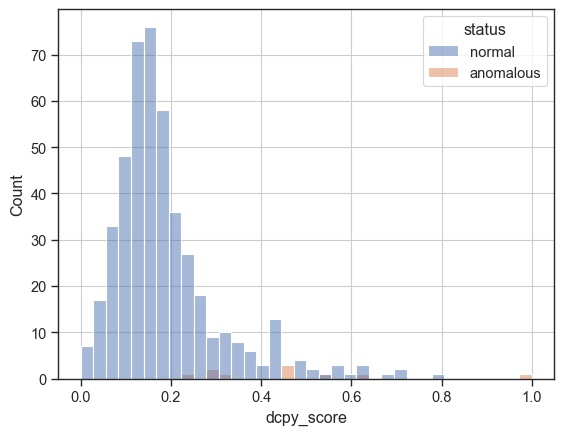

In [18]:
sns.histplot(results_df, x="dcpy_score", hue="status")